# Synthetic graph experiments for topological coverage

This notebook investigates how the Energy-based topological coverage criterion behaves on controlled graph topologies. The analysis has three objectives:

1. visualize configurations whose $\mathcal{H}$ is closest to the balance point;
2. compare the response of the metric across graph families;

For a binary observation vector \(s\), $\mathcal{H}$ combines local attraction and global repulsion:

$$
\mathcal{H}(s)
=
-\mu \sum_{i<j} A_{ij}s_i s_j
+
\gamma \sum_{i<j}
\frac{(1-A_{ij})s_i s_j}{d_{ij}^{2}}.
$$

The effective energy is $E(s)=|\mathcal{H}(s)|$. Configurations near $\mathcal{H}=0$ represent a compromise between locally connected observations and broad topological dispersion.

> **Reproducibility note.** All graph sizes, probabilities, parameter values, $k$-values, and seeds are retained from the exploratory notebook. Generated figures are saved under `examples/figures`.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import numpy as np

# Make sure src is importable
project_root = Path('..').resolve()
sys.path.insert(0, str(project_root / 'src'))
from etc.hamiltonian import Hamiltonian
from etc_utils.phase_diagrams import *

## 2. Visualization helper

The function below:

1. constructs the $\mathcal{H}$ function associated with a graph;
2. computes the values of $\mu$ and $\gamma$;
3. obtains a $k$-node configuration using `sample_k_closest_to_zero`;
4. highlights the selected nodes and saves a publication-resolution figure.

In [2]:
def plot_min_h_example(G, k, seed=42, title=None, layout="kamada_kawai", palette="sunset_ink"):
    Hobj = Hamiltonian(G)
    mu = Hobj.mu_density_aware(G)
    gamma = Hobj.gamma_balancer(mu=mu)
    Hmin, min_nodes = sample_k_closest_to_zero(
        H=Hobj,
        k=int(k),
        mu=mu,
        gamma=gamma,

    )
    min_nodes = sorted(int(x) for x in np.asarray(min_nodes).ravel())

    palettes = {
        "sunset_ink": {
            "edge": "#6B7280",
            "node_bg": "#334155",
            "node_hi": "#F97316",
            "node_hi_edge": "#111827",
            "figure_bg": "#F8F5F0",
            "text": "#1F2937",
        },
        "teal_gold": {
            "edge": "#5B7C99",
            "node_bg": "#264653",
            "node_hi": "#E9C46A",
            "node_hi_edge": "#1B1F24",
            "figure_bg": "#FAF8F2",
            "text": "#1F2937",
        },
    }
    style = palettes.get(palette, palettes["sunset_ink"])

    if layout == "kamada_kawai":
        try:
            pos = nx.kamada_kawai_layout(G)
        except Exception:
            pos = nx.spring_layout(G, seed=seed)
    elif callable(layout):
        pos = layout(G)
    else:
        pos = nx.spring_layout(G, seed=seed)

    fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
    fig.patch.set_facecolor(style["figure_bg"])
    ax.set_facecolor(style["figure_bg"])

    if title is None:
        title = f"Minimum H example for k={k}"
    ax.set_title(f"{title}\nHmin={Hmin:.6g}", color=style["text"])
    ax.axis("off")

    background = [n for n in G.nodes() if n not in min_nodes]

    nx.draw_networkx_edges(G, pos, ax=ax, width=0.4, alpha=0.55, edge_color=style["edge"])
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=background,
        ax=ax,
        node_color=style["node_bg"],
        node_size=42,
        linewidths=0,
    )
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=min_nodes,
        ax=ax,
        node_color=style["node_hi"],
        node_size=120,
        edgecolors=style["node_hi_edge"],
        linewidths=0.8,
    )

    print(f"Graph: n={G.number_of_nodes()}, m={G.number_of_edges()}")
    print(f"mu={mu:.6g}, gamma={gamma:.6g}")
    print(f"k={k} minimum H={Hmin:.6g}")
    print(f"Minimizing nodes: {min_nodes}")

    figures_dir = project_root / "examples/figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

    filename = f"G_{title}_k{k}.png"
    plt.savefig(figures_dir / filename, dpi=300)
    plt.show()

    return fig, ax, Hmin, min_nodes, mu, gamma

## 3. Graph-topology experiments

Each graph family isolates a different structural feature. The numerical settings below are unchanged from the original analysis.

### 3.1 Barbell graph

The barbell graph contains two dense modules joined by a narrow path. It is used to test whether selected nodes remain trapped inside one dense region or extend across the bottleneck.

Graph: n=32, m=141
mu=0.715726, gamma=34.3972
k=7 minimum H=-0.0761474
Minimizing nodes: [1, 14, 21, 23, 26, 30, 31]


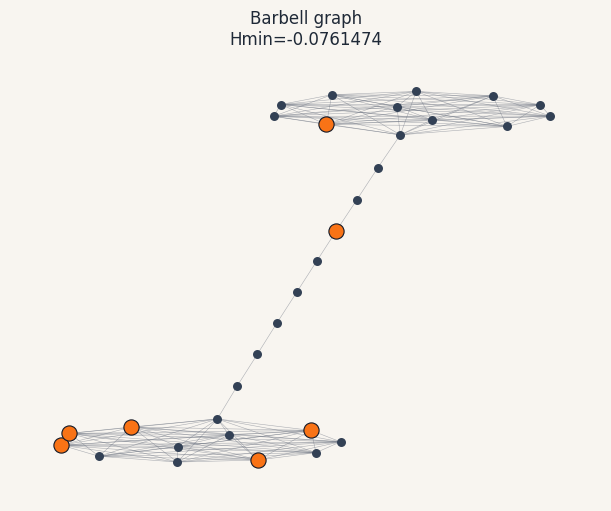

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barbell graph\nHmin=-0.0761474'}>,
 -0.07614744486504321,
 [1, 14, 21, 23, 26, 30, 31],
 0.7157258064516129,
 34.39717741935484)

In [3]:
G_barbell = nx.barbell_graph(12, 8)
plot_min_h_example(G_barbell, k=7, seed=1, title="Barbell graph")

Graph: n=32, m=141
mu=0.715726, gamma=34.3972
k=4 minimum H=-0.0345774
Minimizing nodes: [6, 11, 20, 29]


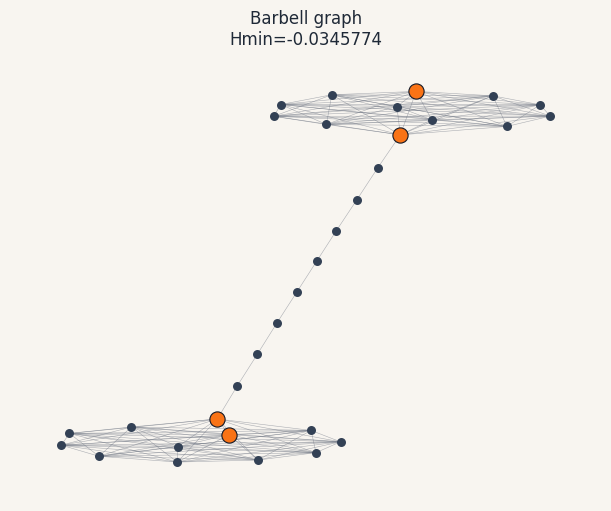

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barbell graph\nHmin=-0.0345774'}>,
 -0.034577359617681935,
 [6, 11, 20, 29],
 0.7157258064516129,
 34.39717741935484)

In [4]:
plot_min_h_example(G_barbell, k=4, seed=1, title="Barbell graph")

Graph: n=32, m=141
mu=0.715726, gamma=34.3972
k=5 minimum H=0.023434
Minimizing nodes: [2, 9, 10, 18, 19]


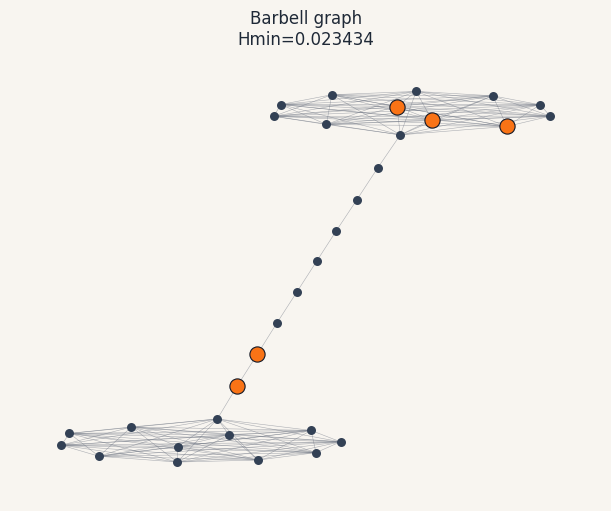

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barbell graph\nHmin=0.023434'}>,
 0.023433999775985814,
 [2, 9, 10, 18, 19],
 0.7157258064516129,
 34.39717741935484)

In [5]:
plot_min_h_example(G_barbell, k=5, seed=1, title="Barbell graph")

### 3.2 Erdős–Rényi graph

The Erdős–Rényi graph provides a comparatively homogeneous random topology. It serves as a reference case with no imposed communities or preferential-attachment hubs.

Graph: n=150, m=604
mu=0.945951, gamma=1.35123
k=5 minimum H=-0.0058091
Minimizing nodes: [34, 59, 94, 103, 120]


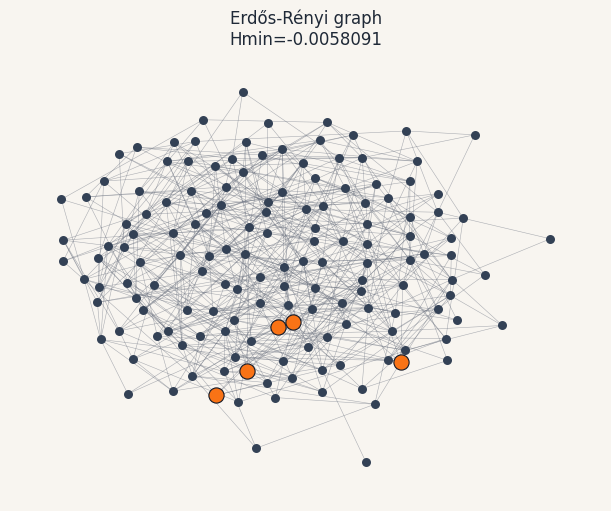

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Erdős-Rényi graph\nHmin=-0.0058091'}>,
 -0.005809097688291853,
 [34, 59, 94, 103, 120],
 0.9459507829977629,
 1.3512304250559286)

In [6]:
G_rand = nx.erdos_renyi_graph(150, 0.05, seed=1)
plot_min_h_example(G_rand, k=5, seed=2, title="Erdős-Rényi graph")

Graph: n=150, m=604
mu=0.945951, gamma=1.35123
k=20 minimum H=-0.00357942
Minimizing nodes: [2, 11, 17, 20, 67, 71, 93, 94, 95, 99, 110, 118, 122, 135, 136, 140, 142, 145, 146, 147]


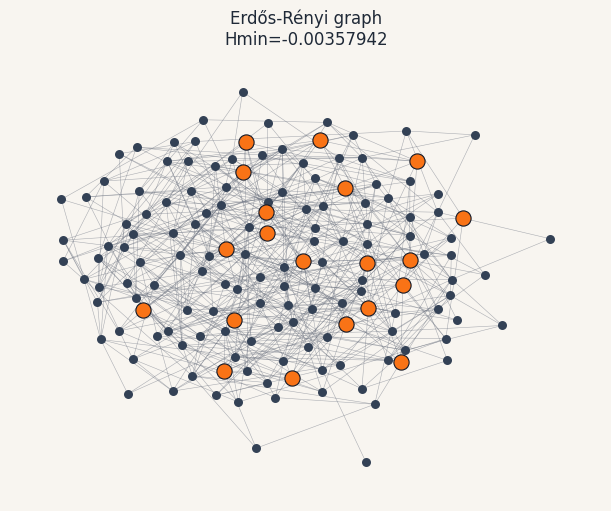

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Erdős-Rényi graph\nHmin=-0.00357942'}>,
 -0.0035794183445148064,
 [2,
  11,
  17,
  20,
  67,
  71,
  93,
  94,
  95,
  99,
  110,
  118,
  122,
  135,
  136,
  140,
  142,
  145,
  146,
  147],
 0.9459507829977629,
 1.3512304250559286)

In [7]:
plot_min_h_example(G_rand, k=20, seed=2, title="Erdős-Rényi graph")

Graph: n=150, m=604
mu=0.945951, gamma=1.35123
k=10 minimum H=0.00312702
Minimizing nodes: [5, 36, 45, 47, 55, 62, 76, 77, 87, 127]


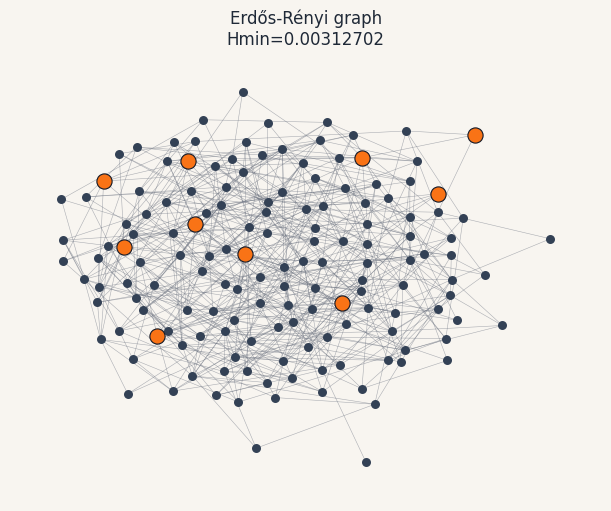

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Erdős-Rényi graph\nHmin=0.00312702'}>,
 0.003127019637085837,
 [5, 36, 45, 47, 55, 62, 76, 77, 87, 127],
 0.9459507829977629,
 1.3512304250559286)

In [8]:
plot_min_h_example(G_rand, k=10, seed=2, title="Erdős-Rényi graph")

### 3.3 Random regular graph

Every node in this graph has degree four. This removes degree heterogeneity and allows the effect of a uniform local environment to be examined.

In [9]:
G_regular = nx.random_regular_graph(4,150)

Graph: n=150, m=300
mu=0.973154, gamma=0.966443
k=10 minimum H=-0.000536913
Minimizing nodes: [11, 27, 44, 49, 59, 69, 87, 98, 144, 146]


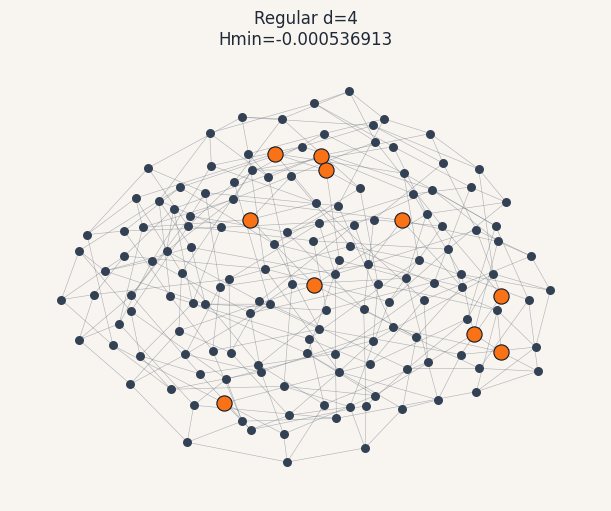

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Regular d=4\nHmin=-0.000536913'}>,
 -0.000536912751677221,
 [11, 27, 44, 49, 59, 69, 87, 98, 144, 146],
 0.9731543624161074,
 0.9664429530201343)

In [10]:
plot_min_h_example(G_regular, k=10, seed=1, title="Regular d=4")

Graph: n=150, m=300
mu=0.973154, gamma=0.966443
k=20 minimum H=0.000268456
Minimizing nodes: [6, 11, 27, 34, 37, 49, 61, 64, 67, 68, 81, 83, 86, 90, 104, 111, 117, 125, 133, 147]


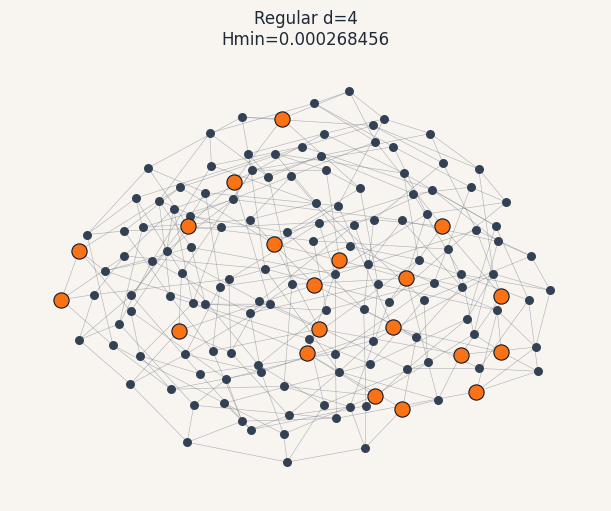

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Regular d=4\nHmin=0.000268456'}>,
 0.0002684563758368341,
 [6,
  11,
  27,
  34,
  37,
  49,
  61,
  64,
  67,
  68,
  81,
  83,
  86,
  90,
  104,
  111,
  117,
  125,
  133,
  147],
 0.9731543624161074,
 0.9664429530201343)

In [11]:
plot_min_h_example(G_regular, k=20, seed=1, title="Regular d=4")

Graph: n=150, m=300
mu=0.973154, gamma=0.966443
k=30 minimum H=0
Minimizing nodes: [4, 6, 10, 18, 19, 20, 27, 33, 34, 36, 39, 40, 42, 50, 55, 56, 60, 61, 66, 67, 70, 72, 85, 86, 108, 120, 124, 128, 140, 141]


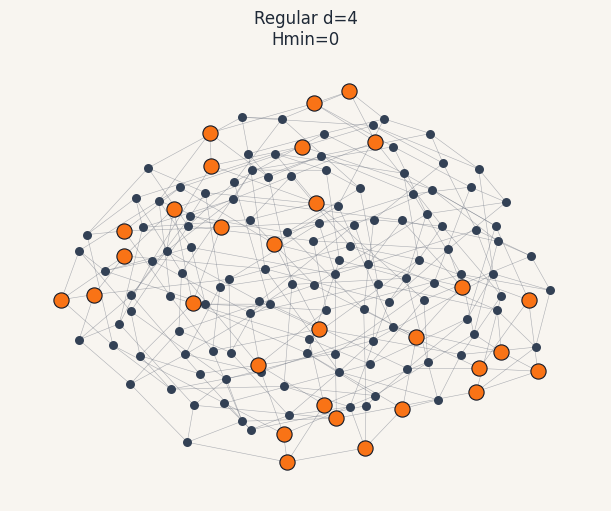

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Regular d=4\nHmin=0'}>,
 0.0,
 [4,
  6,
  10,
  18,
  19,
  20,
  27,
  33,
  34,
  36,
  39,
  40,
  42,
  50,
  55,
  56,
  60,
  61,
  66,
  67,
  70,
  72,
  85,
  86,
  108,
  120,
  124,
  128,
  140,
  141],
 0.9731543624161074,
 0.9664429530201343)

In [12]:
plot_min_h_example(G_regular, k=30, seed=1, title="Regular d=4")

### 3.4 Barabási–Albert graph

The Barabási–Albert graph introduces a heavy-tailed degree distribution through preferential attachment. The sequence of $k$-values is used to observe when high-degree regions begin to appear in the selected configurations.

The `seed` argument in `plot_min_h_example` controls only the fallback spring layout; it does not alter the already generated graph.

In [13]:
G_ba = nx.barabasi_albert_graph(n=200, m=4, seed=42)

Graph: n=200, m=784
mu=0.960603, gamma=0.630352
k=5 minimum H=-0.0106979
Minimizing nodes: [12, 71, 72, 95, 158]


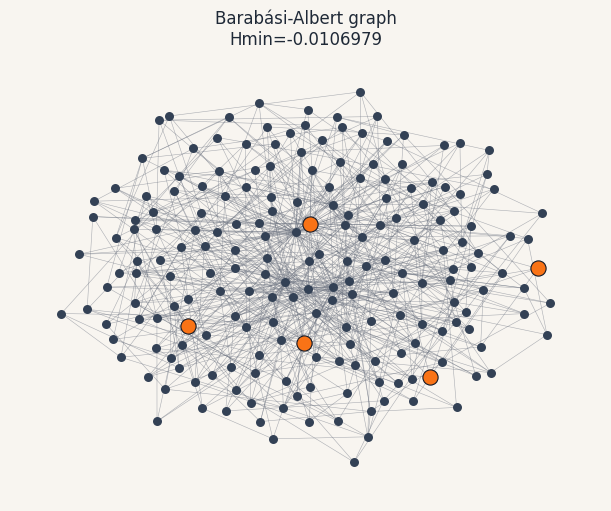

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barabási-Albert graph\nHmin=-0.0106979'}>,
 -0.010697934115019403,
 [12, 71, 72, 95, 158],
 0.9606030150753769,
 0.6303517587939699)

In [14]:
plot_min_h_example(G_ba, k=5, seed=42, title="Barabási-Albert graph")

Graph: n=200, m=784
mu=0.960603, gamma=0.630352
k=6 minimum H=-0.0106979
Minimizing nodes: [39, 77, 116, 134, 142, 172]


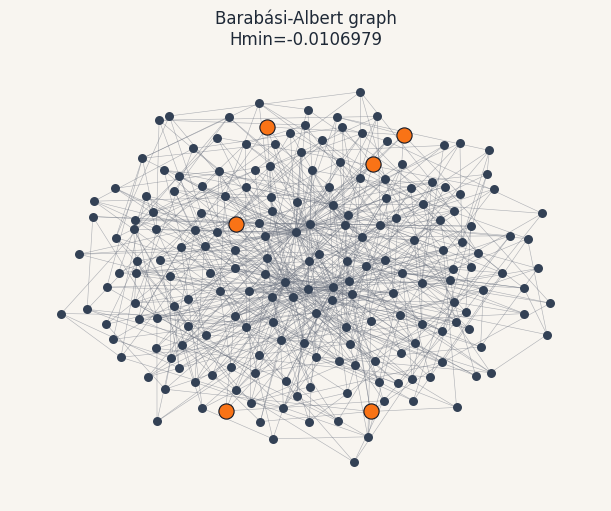

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barabási-Albert graph\nHmin=-0.0106979'}>,
 -0.010697934115019514,
 [39, 77, 116, 134, 142, 172],
 0.9606030150753769,
 0.6303517587939699)

In [15]:
plot_min_h_example(G_ba, k=6, seed=42, title="Barabási-Albert graph")

Graph: n=200, m=784
mu=0.960603, gamma=0.630352
k=7 minimum H=-0.00826354
Minimizing nodes: [30, 47, 48, 114, 152, 178, 196]


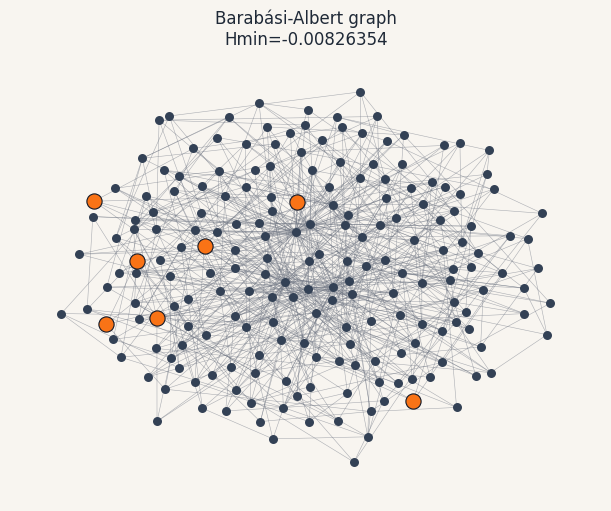

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barabási-Albert graph\nHmin=-0.00826354'}>,
 -0.008263539921831375,
 [30, 47, 48, 114, 152, 178, 196],
 0.9606030150753769,
 0.6303517587939699)

In [16]:
plot_min_h_example(G_ba, k=7, seed=40, title="Barabási-Albert graph")

Graph: n=200, m=784
mu=0.960603, gamma=0.630352
k=8 minimum H=0.00486879
Minimizing nodes: [0, 84, 106, 147, 151, 164, 194, 198]


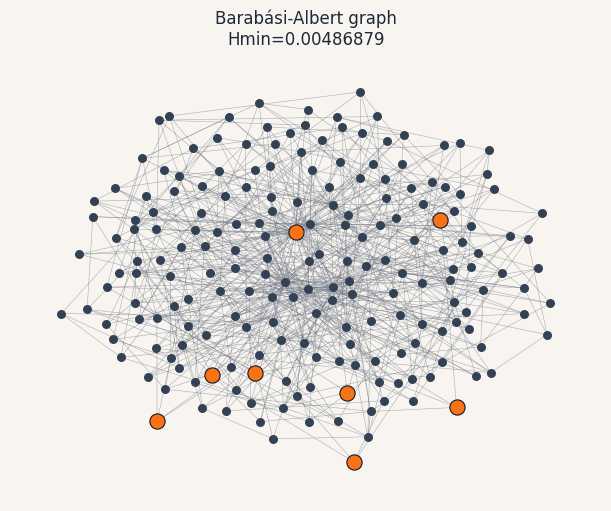

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barabási-Albert graph\nHmin=0.00486879'}>,
 0.004868788386376277,
 [0, 84, 106, 147, 151, 164, 194, 198],
 0.9606030150753769,
 0.6303517587939699)

In [17]:
plot_min_h_example(G_ba, k=8, seed=42, title="Barabási-Albert graph")

Graph: n=200, m=784
mu=0.960603, gamma=0.630352
k=9 minimum H=0.000982691
Minimizing nodes: [6, 15, 29, 53, 62, 76, 93, 95, 156]


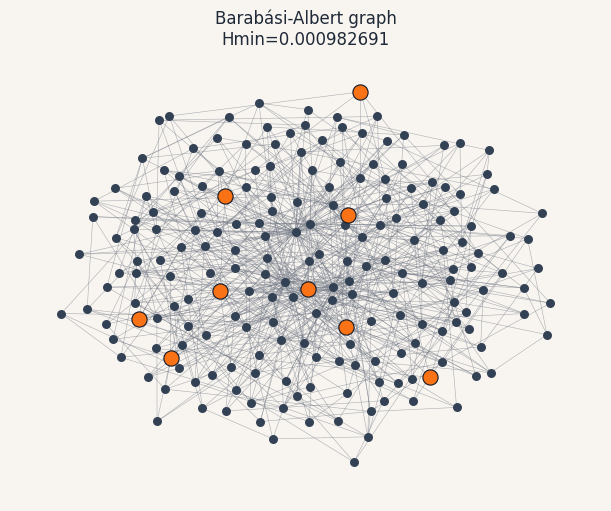

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barabási-Albert graph\nHmin=0.000982691'}>,
 0.0009826912339474525,
 [6, 15, 29, 53, 62, 76, 93, 95, 156],
 0.9606030150753769,
 0.6303517587939699)

In [18]:
plot_min_h_example(G_ba, k=9, seed=42, title="Barabási-Albert graph")

Graph: n=200, m=784
mu=0.960603, gamma=0.630352
k=10 minimum H=-0.00777219
Minimizing nodes: [12, 25, 43, 58, 93, 129, 132, 142, 173, 177]


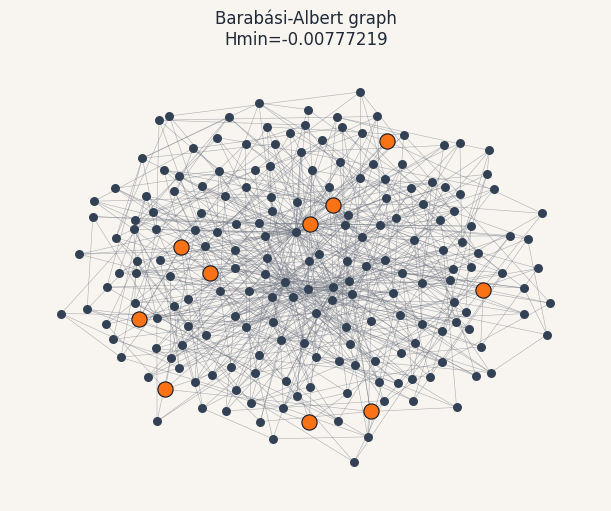

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barabási-Albert graph\nHmin=-0.00777219'}>,
 -0.007772194304857649,
 [12, 25, 43, 58, 93, 129, 132, 142, 173, 177],
 0.9606030150753769,
 0.6303517587939699)

In [19]:
plot_min_h_example(G_ba, k=10, seed=1, title="Barabási-Albert graph")

Graph: n=200, m=784
mu=0.960603, gamma=0.630352
k=15 minimum H=-0.00435511
Minimizing nodes: [4, 9, 24, 32, 36, 49, 101, 114, 132, 158, 164, 171, 173, 177, 178]


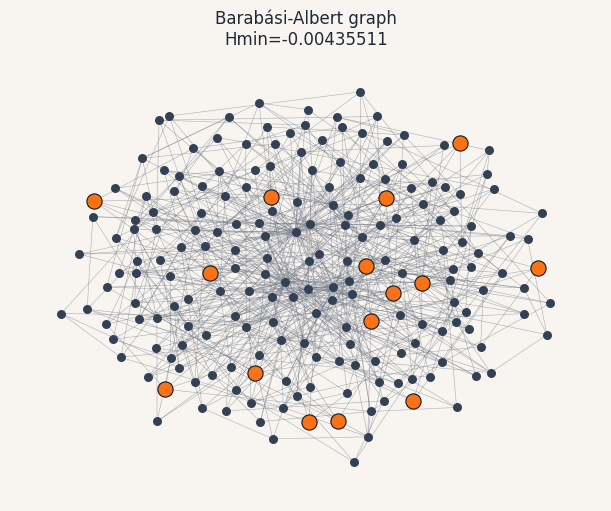

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barabási-Albert graph\nHmin=-0.00435511'}>,
 -0.004355108877721392,
 [4, 9, 24, 32, 36, 49, 101, 114, 132, 158, 164, 171, 173, 177, 178],
 0.9606030150753769,
 0.6303517587939699)

In [20]:
plot_min_h_example(G_ba, k=15, seed=42, title="Barabási-Albert graph")

Graph: n=200, m=784
mu=0.960603, gamma=0.630352
k=20 minimum H=4.46678e-05
Minimizing nodes: [0, 2, 12, 20, 38, 59, 60, 63, 70, 72, 77, 105, 107, 115, 116, 144, 157, 175, 195, 197]


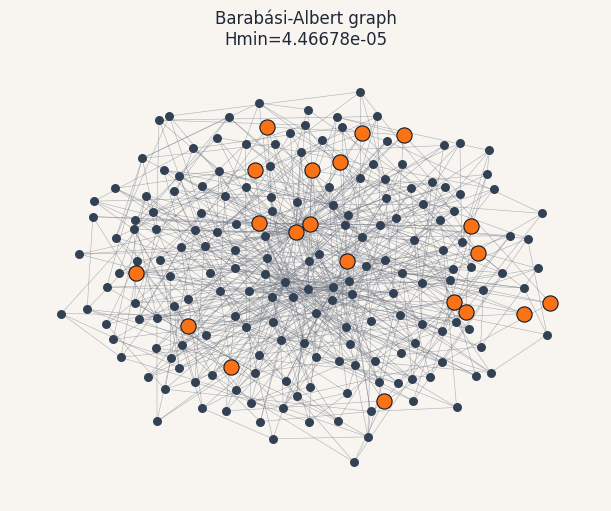

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barabási-Albert graph\nHmin=4.46678e-05'}>,
 4.4667783360097246e-05,
 [0,
  2,
  12,
  20,
  38,
  59,
  60,
  63,
  70,
  72,
  77,
  105,
  107,
  115,
  116,
  144,
  157,
  175,
  195,
  197],
 0.9606030150753769,
 0.6303517587939699)

In [21]:
plot_min_h_example(G_ba, k=20, seed=1, title="Barabási-Albert graph")

Graph: n=200, m=784
mu=0.960603, gamma=0.630352
k=25 minimum H=0.000558347
Minimizing nodes: [0, 1, 6, 26, 28, 45, 55, 68, 74, 76, 81, 82, 86, 89, 107, 125, 128, 144, 145, 147, 152, 170, 180, 182, 193]


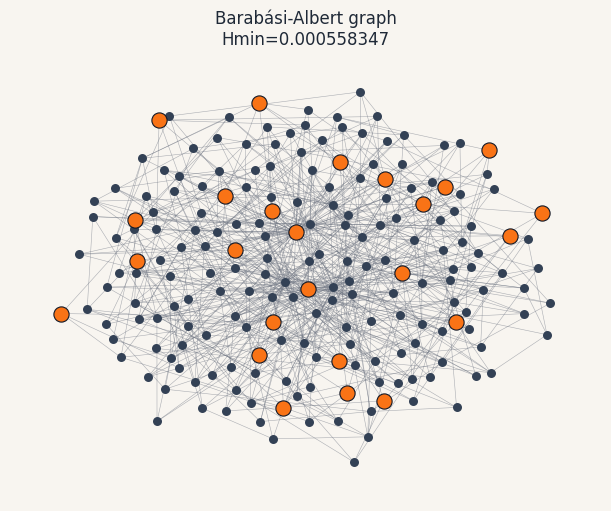

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barabási-Albert graph\nHmin=0.000558347'}>,
 0.0005583472920136501,
 [0,
  1,
  6,
  26,
  28,
  45,
  55,
  68,
  74,
  76,
  81,
  82,
  86,
  89,
  107,
  125,
  128,
  144,
  145,
  147,
  152,
  170,
  180,
  182,
  193],
 0.9606030150753769,
 0.6303517587939699)

In [22]:
plot_min_h_example(G_ba, k=25, seed=42, title="Barabási-Albert graph")

Graph: n=200, m=784
mu=0.960603, gamma=0.630352
k=30 minimum H=0.000111669
Minimizing nodes: [0, 2, 6, 8, 9, 16, 20, 21, 26, 32, 38, 45, 55, 74, 76, 83, 84, 95, 98, 113, 121, 125, 128, 136, 150, 154, 160, 161, 184, 185]


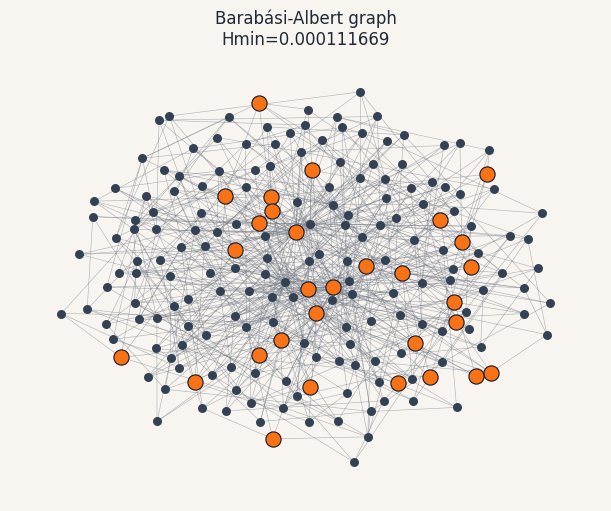

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barabási-Albert graph\nHmin=0.000111669'}>,
 0.00011166945840557219,
 [0,
  2,
  6,
  8,
  9,
  16,
  20,
  21,
  26,
  32,
  38,
  45,
  55,
  74,
  76,
  83,
  84,
  95,
  98,
  113,
  121,
  125,
  128,
  136,
  150,
  154,
  160,
  161,
  184,
  185],
 0.9606030150753769,
 0.6303517587939699)

In [23]:
plot_min_h_example(G_ba, k=30, seed=42, title="Barabási-Albert graph")

Graph: n=200, m=784
mu=0.960603, gamma=0.630352
k=35 minimum H=0.000156337
Minimizing nodes: [3, 5, 6, 8, 12, 13, 14, 16, 17, 21, 23, 24, 28, 33, 34, 35, 52, 65, 78, 85, 95, 97, 98, 120, 121, 122, 137, 146, 164, 166, 175, 176, 185, 186, 199]


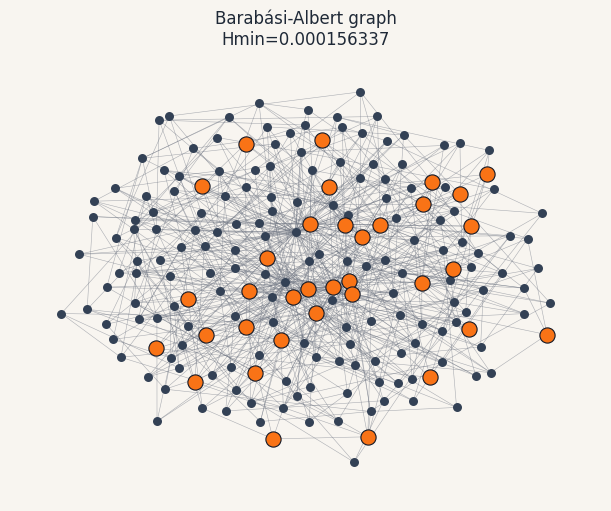

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barabási-Albert graph\nHmin=0.000156337'}>,
 0.00015633724176211672,
 [3,
  5,
  6,
  8,
  12,
  13,
  14,
  16,
  17,
  21,
  23,
  24,
  28,
  33,
  34,
  35,
  52,
  65,
  78,
  85,
  95,
  97,
  98,
  120,
  121,
  122,
  137,
  146,
  164,
  166,
  175,
  176,
  185,
  186,
  199],
 0.9606030150753769,
 0.6303517587939699)

In [24]:
plot_min_h_example(G_ba, k=35, seed=42, title="Barabási-Albert graph")

Graph: n=200, m=784
mu=0.960603, gamma=0.630352
k=40 minimum H=0.000201005
Minimizing nodes: [0, 3, 4, 5, 6, 7, 8, 10, 18, 29, 30, 36, 37, 40, 42, 48, 61, 64, 68, 81, 89, 96, 98, 103, 111, 119, 120, 127, 128, 139, 143, 149, 150, 160, 170, 179, 183, 185, 194, 199]


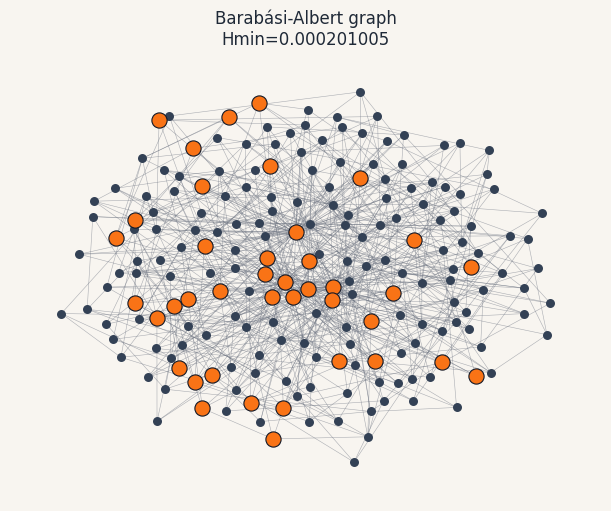

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barabási-Albert graph\nHmin=0.000201005'}>,
 0.00020100502511866125,
 [0,
  3,
  4,
  5,
  6,
  7,
  8,
  10,
  18,
  29,
  30,
  36,
  37,
  40,
  42,
  48,
  61,
  64,
  68,
  81,
  89,
  96,
  98,
  103,
  111,
  119,
  120,
  127,
  128,
  139,
  143,
  149,
  150,
  160,
  170,
  179,
  183,
  185,
  194,
  199],
 0.9606030150753769,
 0.6303517587939699)

In [25]:
plot_min_h_example(G_ba, k=40, seed=42, title="Barabási-Albert graph")

### 3.5 Stochastic block models

The first stochastic block model has strong within-community connectivity $(p_{\mathrm{in}}=0.3)$ and weak between-community connectivity $(p_{\mathrm{out}}=0.01)$. It therefore provides an explicit modular test case.

In [26]:
# --- Parameters ---
sizes = [50, 50, 50]  # 3 communities
p_in = 0.3            # intra-community probability
p_out = 0.01          # inter-community probability

# Probability matrix
probs = [
    [p_in, p_out, p_out],
    [p_out, p_in, p_out],
    [p_out, p_out, p_in]
]

# --- Generate SBM ---
G_SBM_in = nx.stochastic_block_model(sizes, probs, seed=42)

The helper below computes the expected graph density from the block sizes and connection-probability matrix. Block labels are also extracted for possible community-level diagnostics.

In [27]:
def generate_sbm(n_blocks=3, block_size=50, p_in=0.3, p_out=0.02, seed=42):
    sizes = [block_size] * n_blocks
    
    probs = [[p_out]*n_blocks for _ in range(n_blocks)]
    for i in range(n_blocks):
        probs[i][i] = p_in
    
    G = nx.stochastic_block_model(sizes, probs, seed=seed)
    
    return G

Graph: n=150, m=1163
mu=0.895928, gamma=1.66515
k=3 minimum H=-0.0633557
Minimizing nodes: [119, 138, 143]


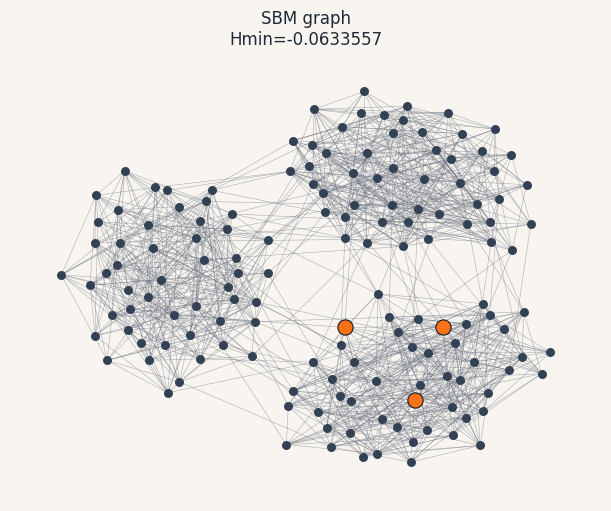

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'SBM graph\nHmin=-0.0633557'}>,
 -0.06335570469798657,
 [119, 138, 143],
 0.8959284116331097,
 1.6651454138702462)

In [28]:
plot_min_h_example(G_SBM_in, k=3, seed=1, title="SBM graph")

Graph: n=150, m=1163
mu=0.895928, gamma=1.66515
k=10 minimum H=-0.0202038
Minimizing nodes: [51, 56, 66, 82, 85, 89, 98, 109, 121, 137]


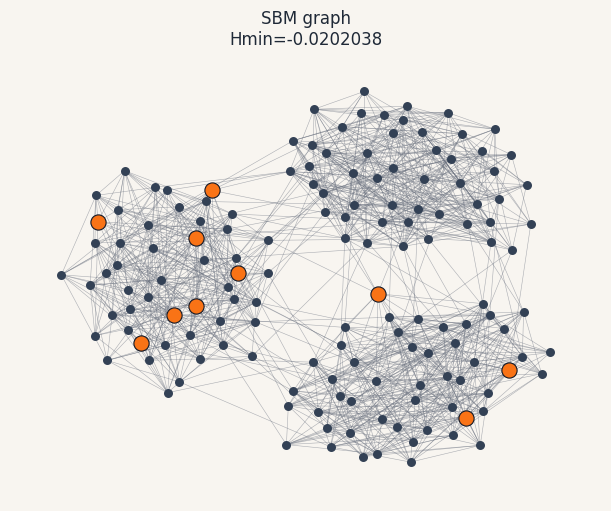

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'SBM graph\nHmin=-0.0202038'}>,
 -0.020203827989062617,
 [51, 56, 66, 82, 85, 89, 98, 109, 121, 137],
 0.8959284116331097,
 1.6651454138702462)

In [29]:
plot_min_h_example(G_SBM_in, k=10, seed=1, title="SBM graph")

Graph: n=150, m=1163
mu=0.895928, gamma=1.66515
k=20 minimum H=-0.0054089
Minimizing nodes: [15, 29, 35, 42, 45, 49, 52, 55, 61, 68, 69, 70, 75, 87, 88, 91, 92, 98, 99, 147]


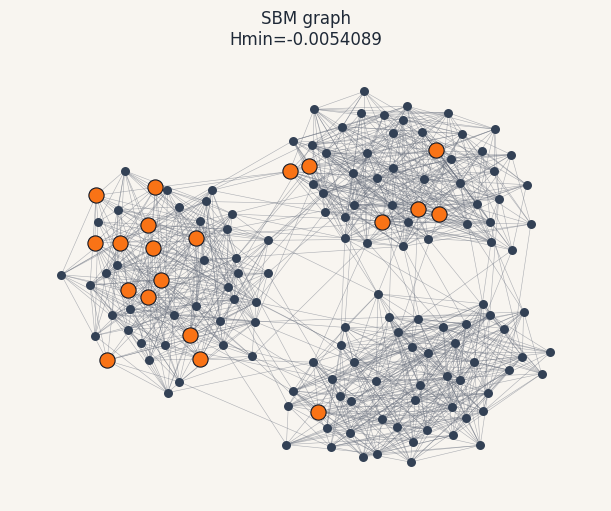

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'SBM graph\nHmin=-0.0054089'}>,
 -0.005408898831710474,
 [15,
  29,
  35,
  42,
  45,
  49,
  52,
  55,
  61,
  68,
  69,
  70,
  75,
  87,
  88,
  91,
  92,
  98,
  99,
  147],
 0.8959284116331097,
 1.6651454138702462)

In [30]:
plot_min_h_example(G_SBM_in, k=20, seed=1, title="SBM graph")

#### Contrast SBM with stronger between-block connectivity

The second SBM reverses the usual modular relation by setting $p_{\mathrm{out}}=0.05$ and $p_{\mathrm{in}}=0.03$. It is therefore a contrast topology rather than a strongly modular network.

In [31]:
G_SBM_out = generate_sbm(n_blocks=3, block_size=50, p_in=0.03, p_out=0.05, seed=42)

Graph: n=150, m=471
mu=0.957852, gamma=1.05369
k=10 minimum H=0.00324198
Minimizing nodes: [11, 45, 48, 60, 61, 65, 85, 110, 116, 142]


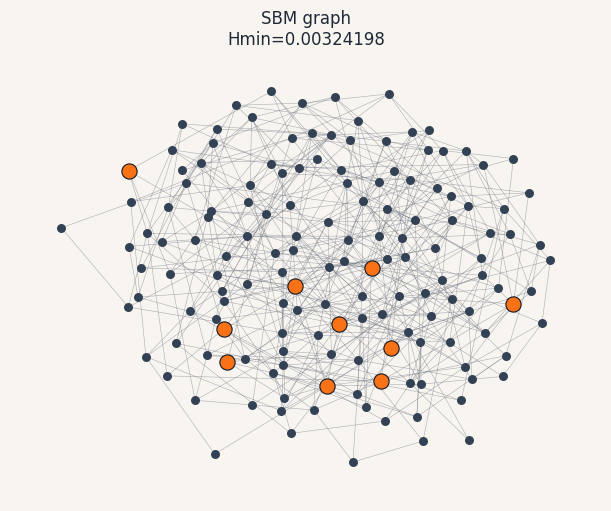

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'SBM graph\nHmin=0.00324198'}>,
 0.003241983594332254,
 [11, 45, 48, 60, 61, 65, 85, 110, 116, 142],
 0.9578523489932886,
 1.0536912751677854)

In [32]:
plot_min_h_example(G_SBM_out, k=10, seed=42, title="SBM graph")

Graph: n=150, m=471
mu=0.957852, gamma=1.05369
k=20 minimum H=-0.000296421
Minimizing nodes: [10, 12, 15, 22, 27, 34, 53, 55, 64, 67, 74, 81, 83, 93, 94, 119, 120, 121, 142, 145]


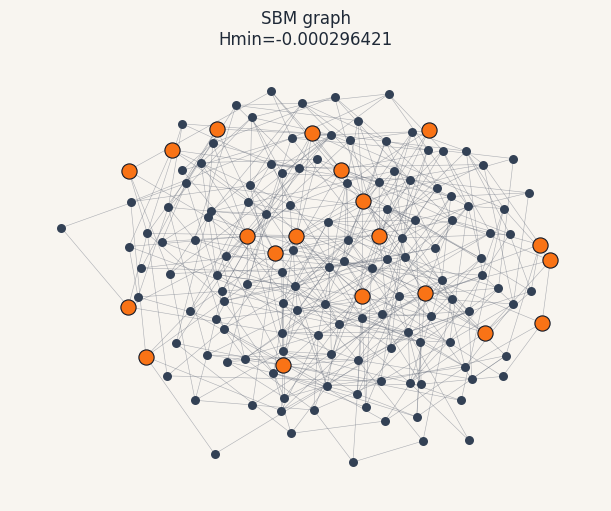

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'SBM graph\nHmin=-0.000296421'}>,
 -0.00029642058165535445,
 [10,
  12,
  15,
  22,
  27,
  34,
  53,
  55,
  64,
  67,
  74,
  81,
  83,
  93,
  94,
  119,
  120,
  121,
  142,
  145],
 0.9578523489932886,
 1.0536912751677854)

In [33]:
plot_min_h_example(G_SBM_out, k=20, seed=42, title="SBM graph")

## 4. Landscape diagrams

The landscape diagrams summarize the $\mathcal{H}$ response as the number of selected nodes $k$ and the scaling parameter $s$ vary. Contours mark iso-H regions, while an optional vertical line highlights a chosen scale.

The standalone call below reproduces the original Erdős–Rényi landscape-diagram calculation and provides the arrays used by the plotting utility.

In [34]:
k_vals, ratio, H = phase_diagram_values(
        Hamiltonian=Hamiltonian(G_rand),
        mu=0.94,
        gamma=1.35,
        kmax=20,
        scale_max=4,
        scale_steps=0.25,
        k_steps=1,
    )

TypeError: phase_diagram_values() missing 2 required positional arguments: 'A' and 'D2'

### 4.1 Phase-diagram plotting utility

In [ ]:
def plot_phase_diagram_for_graph(
    G,
    *,
    mu=1.0,
    gamma=1.0,
    kmax=20,
    scale_max=12,
    scale_steps=1,
    k_steps=1,
    cmap="magma",
    contour_color="white",
    title="Phase Diagram",
    show_transitions=True,
    transition_levels=8,
    highlight_scale=None,
    highlight_color="red",
    highlight_linewidth=2.0,
):
    H_obj = Hamiltonian(G)

    k_values, ratio, H = phase_diagram_values(
        Hamiltonian=H_obj,
        mu=float(mu),
        gamma=float(gamma),
        kmax=int(kmax),
        scale_max=float(scale_max),
        scale_steps=float(scale_steps),
        k_steps=int(k_steps),
    )

    # k_values, ratio, H are now numpy arrays
    # H shape: (len(k_values), len(scale_values))
    # ratio shape: (len(k_values), len(scale_values))
    
    scale_values = np.arange(0.25, scale_max + scale_steps, scale_steps)
    
    # Compute extent: [left, right, bottom, top]
    scale_min = scale_values[0]
    scale_max_val = scale_values[-1]
    k_min = k_values[0]
    k_max = k_values[-1]
    extent = [scale_min, scale_max_val, k_min, k_max]

    fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
    im = ax.imshow(
        H,
        aspect="auto",
        origin="lower",
        interpolation="bilinear",
        cmap=cmap,
        extent=extent,
    )

    # Add transition boundaries (contour lines)
    if show_transitions:
        h_min, h_max = np.nanmin(H), np.nanmax(H)
        contour_levels = np.linspace(h_min, h_max, transition_levels)
        cs = ax.contour(
            scale_values,
            k_values,
            H,
            levels=contour_levels,
            colors=contour_color,
            linewidths=0.7,
            alpha=0.5,
        )
        ax.clabel(cs, inline=True, fontsize=7, fmt="%.3f")

    # Add vertical line at specific mu/gamma value
    if highlight_scale is not None:
        ax.axvline(
            x=float(highlight_scale),
            color=highlight_color,
            linestyle="--",
            linewidth=highlight_linewidth,
            alpha=0.8,
            label=f"s = {highlight_scale:.3f}",
        )
        ax.legend(loc="upper right")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$H \approx 0$")
    ax.set_xlabel(r"$s$")
    ax.set_ylabel(r"$k$")
    ax.set_title(title)

    print(f"Graph: n={G.number_of_nodes()}, m={G.number_of_edges()}")
    print("Computed phase diagram.")
    if show_transitions:
        print(f"Transition boundaries shown at {transition_levels} levels.")
    if highlight_scale is not None:
        print(f"Highlighted transition line at μ/γ = {highlight_scale:.3f}")

    figures_dir = project_root / "examples/figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

    filename = f"PD_{title}.png"
    plt.savefig(figures_dir / filename, dpi=300)
    plt.show()

    return fig, ax, (k_values, ratio, H)

### 4.2 Topology-specific phase diagrams

The following cells preserve the original graph-specific values of $\mu$, $\gamma$, $k_{\max}$, and the scale range.

Graph: n=200, m=784
Computed phase diagram.
Transition boundaries shown at 8 levels.


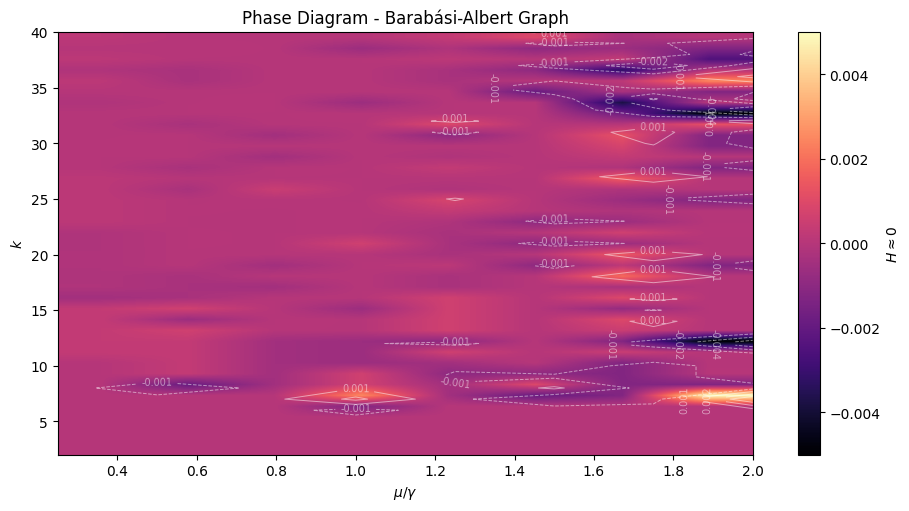

(<Figure size 900x500 with 2 Axes>,
 <Axes: title={'center': 'Phase Diagram - Barabási-Albert Graph'}, xlabel='$\\mu / \\gamma$', ylabel='$k$'>,
 (array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
         19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
         36, 37, 38, 39, 40]),
  array([[6.0952381 , 3.04761905, 2.03174603, 1.52380952, 1.21904762,
          1.01587302, 0.8707483 , 0.76190476],
         [6.0952381 , 3.04761905, 2.03174603, 1.52380952, 1.21904762,
          1.01587302, 0.8707483 , 0.76190476],
         [6.0952381 , 3.04761905, 2.03174603, 1.52380952, 1.21904762,
          1.01587302, 0.8707483 , 0.76190476],
         [6.0952381 , 3.04761905, 2.03174603, 1.52380952, 1.21904762,
          1.01587302, 0.8707483 , 0.76190476],
         [6.0952381 , 3.04761905, 2.03174603, 1.52380952, 1.21904762,
          1.01587302, 0.8707483 , 0.76190476],
         [6.0952381 , 3.04761905, 2.03174603, 1.52380952, 1.21904762,
          1.015

In [ ]:
plot_phase_diagram_for_graph(G_ba,gamma=0.63,
                     mu=0.96,
                     kmax=40, 
                     scale_max=2, 
                     scale_steps=0.25, 
                     k_steps=1,
                     title="Phase Diagram - Barabási-Albert Graph")

In [ ]:
plot_phase_diagram_for_graph(G_regular,gamma=0.4,
                     mu=0.96,
                     kmax=40, 
                     scale_max=12, 
                     scale_steps=1, 
                     k_steps=1,
                     title="Phase Diagram - Regular Graph (d=4)")

KeyboardInterrupt: 

Graph: n=32, m=141
Computed phase diagram.
Transition boundaries shown at 8 levels.


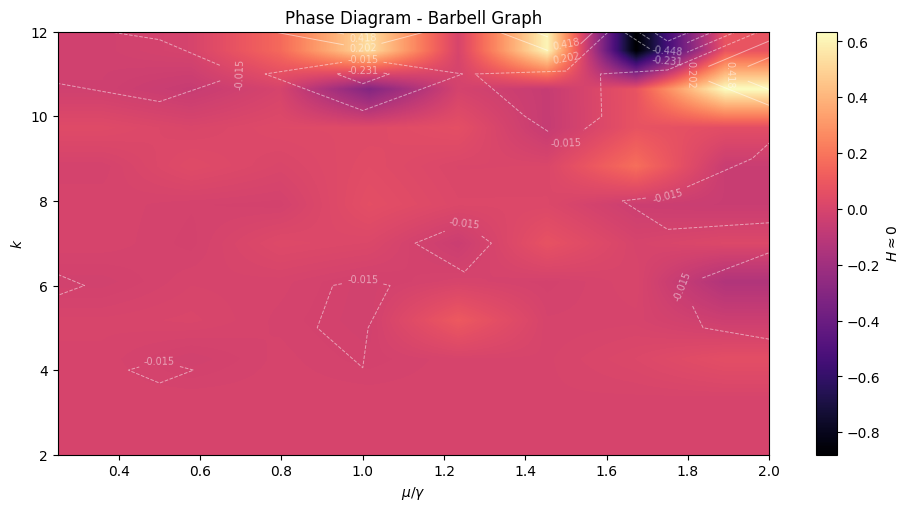

(<Figure size 900x500 with 2 Axes>,
 <Axes: title={'center': 'Phase Diagram - Barbell Graph'}, xlabel='$\\mu / \\gamma$', ylabel='$k$'>,
 (array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
  array([[0.08411765, 0.04205882, 0.02803922, 0.02102941, 0.01682353,
          0.01401961, 0.01201681, 0.01051471],
         [0.08411765, 0.04205882, 0.02803922, 0.02102941, 0.01682353,
          0.01401961, 0.01201681, 0.01051471],
         [0.08411765, 0.04205882, 0.02803922, 0.02102941, 0.01682353,
          0.01401961, 0.01201681, 0.01051471],
         [0.08411765, 0.04205882, 0.02803922, 0.02102941, 0.01682353,
          0.01401961, 0.01201681, 0.01051471],
         [0.08411765, 0.04205882, 0.02803922, 0.02102941, 0.01682353,
          0.01401961, 0.01201681, 0.01051471],
         [0.08411765, 0.04205882, 0.02803922, 0.02102941, 0.01682353,
          0.01401961, 0.01201681, 0.01051471],
         [0.08411765, 0.04205882, 0.02803922, 0.02102941, 0.01682353,
          0.01401961, 0.01201681, 0.

In [ ]:
plot_phase_diagram_for_graph(G_barbell,gamma=34,
                     mu=0.715,
                     kmax=12, 
                     scale_max=2, 
                     scale_steps=0.25, 
                     k_steps=1,
                     title="Phase Diagram - Barbell Graph")

Graph: n=150, m=1163
Computed phase diagram.
Transition boundaries shown at 8 levels.


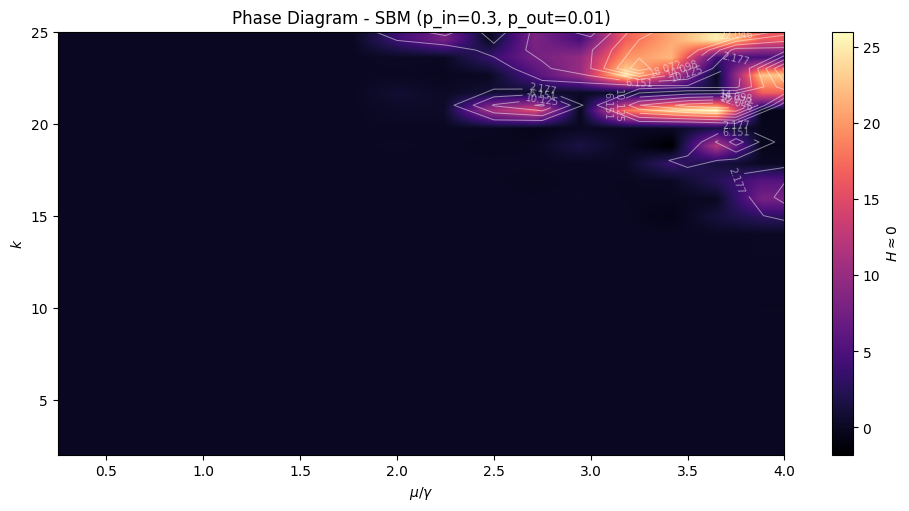

(<Figure size 900x500 with 2 Axes>,
 <Axes: title={'center': 'Phase Diagram - SBM (p_in=0.3, p_out=0.01)'}, xlabel='$\\mu / \\gamma$', ylabel='$k$'>,
 (array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
         19, 20, 21, 22, 23, 24, 25]),
  array([[2.14457831, 1.07228916, 0.71485944, 0.53614458, 0.42891566,
          0.35742972, 0.30636833, 0.26807229, 0.23828648, 0.21445783,
          0.19496166, 0.17871486, 0.16496756, 0.15318417, 0.14297189,
          0.13403614],
         [2.14457831, 1.07228916, 0.71485944, 0.53614458, 0.42891566,
          0.35742972, 0.30636833, 0.26807229, 0.23828648, 0.21445783,
          0.19496166, 0.17871486, 0.16496756, 0.15318417, 0.14297189,
          0.13403614],
         [2.14457831, 1.07228916, 0.71485944, 0.53614458, 0.42891566,
          0.35742972, 0.30636833, 0.26807229, 0.23828648, 0.21445783,
          0.19496166, 0.17871486, 0.16496756, 0.15318417, 0.14297189,
          0.13403614],
         [2.14457831, 1.07228916, 0

In [ ]:
plot_phase_diagram_for_graph(
    G_SBM_in,
    mu=0.89,
    gamma=1.66,
    kmax=25,
    scale_max=4,
    scale_steps=0.25,
    k_steps=1,
    title="Phase Diagram - SBM (p_in=0.3, p_out=0.01)",
)

Graph: n=150, m=604
Computed phase diagram.
Transition boundaries shown at 8 levels.


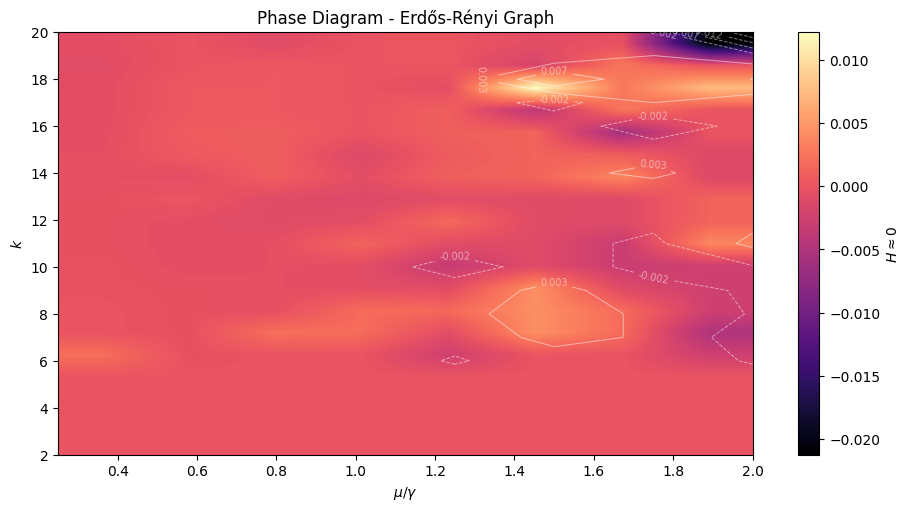

(<Figure size 900x500 with 2 Axes>,
 <Axes: title={'center': 'Phase Diagram - Erdős-Rényi Graph'}, xlabel='$\\mu / \\gamma$', ylabel='$k$'>,
 (array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
         19, 20]),
  array([[2.78518519, 1.39259259, 0.92839506, 0.6962963 , 0.55703704,
          0.46419753, 0.3978836 , 0.34814815],
         [2.78518519, 1.39259259, 0.92839506, 0.6962963 , 0.55703704,
          0.46419753, 0.3978836 , 0.34814815],
         [2.78518519, 1.39259259, 0.92839506, 0.6962963 , 0.55703704,
          0.46419753, 0.3978836 , 0.34814815],
         [2.78518519, 1.39259259, 0.92839506, 0.6962963 , 0.55703704,
          0.46419753, 0.3978836 , 0.34814815],
         [2.78518519, 1.39259259, 0.92839506, 0.6962963 , 0.55703704,
          0.46419753, 0.3978836 , 0.34814815],
         [2.78518519, 1.39259259, 0.92839506, 0.6962963 , 0.55703704,
          0.46419753, 0.3978836 , 0.34814815],
         [2.78518519, 1.39259259, 0.92839506, 0.6962963 , 0.5

In [ ]:
plot_phase_diagram_for_graph(G_rand,gamma=1.35,
                     mu=0.94,
                     kmax=20, 
                     scale_max=2, 
                     scale_steps=0.25, 
                     k_steps=1,
                     title="Phase Diagram - Erdős-Rényi Graph") 

## 5. Structural interpretation of the Barabási–Albert selections

The Barabási–Albert topology is examined in greater detail because its degree heterogeneity provides a direct test of whether low-energy configurations preferentially select hubs or nodes located near hubs.

### 5.1 Degree distribution and highlighted selected-node degrees

The degree distribution is shown on logarithmic axes. The highlighted degree classes correspond to values observed in selected configurations for different $k$.

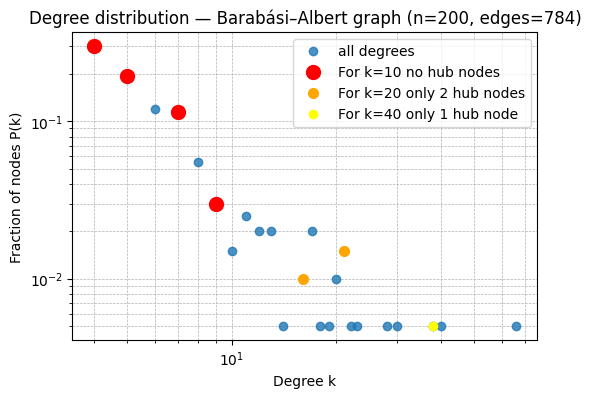

In [35]:
# Extract the empirical degree distribution.
degrees = [degree for _, degree in G_ba.degree()]
unique, counts = np.unique(degrees, return_counts=True)
freq = counts / counts.sum()

plt.figure(figsize=(6, 4))

# Plot the complete degree distribution.
plt.loglog(
    unique,
    freq,
    "o",
    markersize=6,
    label="all degrees",
    alpha=0.8,
)

# Degree classes highlighted in the original analysis.
highlight_degs = {4, 9, 5, 7}
highlight_degs_2 = {21, 16}
highlight_degs_3 = {38, 61}

mask = np.isin(unique, list(highlight_degs))
mask2 = np.isin(unique, list(highlight_degs_2))
mask3 = np.isin(unique, list(highlight_degs_3))

plt.loglog(
    unique[mask],
    freq[mask],
    "o",
    color="red",
    markersize=10,
    label="For k=10 no hub nodes",
)
plt.loglog(
    unique[mask2],
    freq[mask2],
    "o",
    color="orange",
    markersize=7,
    label="For k=20 only 2 hub nodes",
)
plt.loglog(
    unique[mask3],
    freq[mask3],
    "o",
    color="yellow",
    markersize=6,
    label="For k=40 only 1 hub node",
)

plt.xlabel("Degree k")
plt.ylabel("Fraction of nodes P(k)")
plt.title(
    "Degree distribution — Barabási–Albert graph "
    f"(n={G_ba.number_of_nodes()}, edges={G_ba.number_of_edges()})"
)
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.legend()

figures_dir = project_root / "examples/figures"
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(
    figures_dir / "degree_distribution_BA_highlighted.png",
    dpi=300,
)
plt.show()

### 5.2 Hub definition and node-to-hub distance

Hubs are defined as nodes at or above the 95% of the degree distribution. For every node, the shortest-path distance to the nearest hub is then computed.

In [ ]:
# Map each node to its degree.
nodes = G_ba.nodes()
degrees = {node: G_ba.degree(node) for node in nodes}

# Degree threshold defining the upper 5% of the distribution.
threshold = np.percentile(list(degrees.values()), 95)

# Identify hubs and retain their degree values for inspection.
hubs = [node for node, degree in degrees.items() if degree >= threshold]
hubs_degrees = {node: degrees[node] for node in hubs}

# Compute the minimum shortest-path distance from every node to any hub.
distance_to_hub = {}

for node in G_ba.nodes():
    distance_to_hub[node] = min(
        nx.shortest_path_length(G_ba, node, hub)
        for hub in hubs
    )

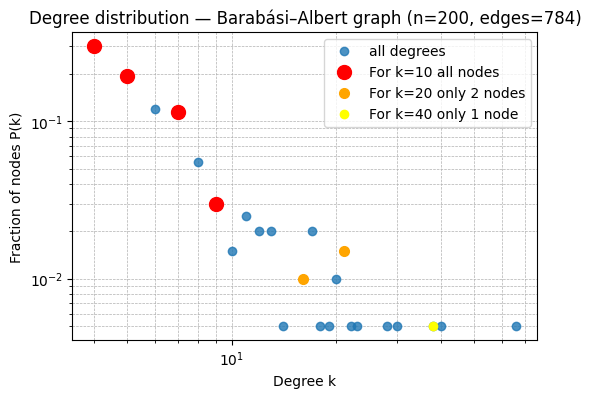

In [ ]:
degrees = [d for _, d in G_ba.degree()]
unique, counts = np.unique(degrees, return_counts=True)
freq = counts / counts.sum()

plt.figure(figsize=(6,4))
# plot all degree points
plt.loglog(unique, freq, 'o', markersize=6, label='all degrees', alpha=0.8)

# highlight specific degrees
highlight_degs = {4, 9, 5,7}
highlight_degs_2 = {21,16}
highlight_degs_3 = {38,61}
mask = np.isin(unique, list(highlight_degs))
mask2 = np.isin(unique, list(highlight_degs_2))
mask3 = np.isin(unique, list(highlight_degs_3))

plt.loglog(unique[mask], freq[mask], 'o', color='red', markersize=10, label='For k=10 all nodes')
plt.loglog(unique[mask2], freq[mask2], 'o', color='orange', markersize=7, label='For k=20 only 2 nodes')
plt.loglog(unique[mask3], freq[mask3], 'o', color='yellow', markersize=6, label='For k=40 only 1 node')

plt.xlabel('Degree k')
plt.ylabel('Fraction of nodes P(k)')
plt.title(f'Degree distribution — Barabási–Albert graph (n={G_ba.number_of_nodes()}, edges={G_ba.number_of_edges()})')
plt.grid(True, which='both', ls='--', linewidth=0.5)
plt.legend()

figures_dir = project_root / "examples/figures"
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / "degree_distribution_BA_highlighted.png", dpi=300)
plt.show()

In [ ]:
nodes = G_ba.nodes()
degrees = {n: G_ba.degree(n) for n in nodes}

In [ ]:
threshold = np.percentile(list(degrees.values()), 95)

In [ ]:
hubs = [n for n, d in degrees.items() if d >= threshold]
hubs_degrees = {n: degrees[n] for n in hubs}

In [ ]:
distance_to_hub = {}

for node in G_ba.nodes():
    distance_to_hub[node] = min(
        nx.shortest_path_length(G_ba, node, hub)
        for hub in hubs
    )

In [ ]:
min_nodes10 = [29, 51, 56, 70, 129, 161, 162, 186, 190, 198]

In [ ]:
dist_10 = [distance_to_hub[node] for node in min_nodes10]

In [ ]:
min_nodes20 = [4, 7, 22, 45, 46, 51, 53, 56, 57, 68, 100, 102, 104, 117, 122, 126, 144, 159, 174, 190]

In [ ]:
dist_20=[distance_to_hub[node] for node in min_nodes20]

In [ ]:
min_nodes40 = [0, 3, 5, 9, 12, 20, 23, 32, 34, 49, 55, 74, 87, 88, 89, 91, 96, 99, 106, 112, 121, 126, 127, 131, 137, 138, 149, 155, 167, 168, 171, 172, 175, 176, 180, 185, 188, 191, 195, 197]

In [ ]:
dist_40 = [distance_to_hub[node] for node in min_nodes40]

In [ ]:
min_nodes15 = [12, 29, 31, 34, 45, 47, 59, 66, 68, 88, 117, 135, 151, 194, 198]
min_nodes25 = [4, 5, 13, 14, 20, 28, 30, 36, 41, 42, 44, 46, 59, 62, 66, 73, 81, 87, 90, 120, 129, 158, 164, 169, 184]
min_nodes30 = [0, 1, 6, 8, 9, 12, 13, 31, 44, 46, 72, 77, 79, 85, 87, 101, 112, 117, 129, 133, 135, 140, 142, 148, 151, 172, 173, 183, 185, 197]
min_nodes35 = [0, 3, 8, 17, 23, 34, 39, 42, 62, 65, 69, 71, 75, 77, 83, 86, 93, 95, 109, 111, 112, 116, 126, 130, 132, 133, 144, 159, 163, 170, 182, 183, 196, 198, 199]

In [ ]:
dist_15 = [distance_to_hub[node] for node in min_nodes15]
dist_25 = [distance_to_hub[node] for node in min_nodes25]
dist_30 = [distance_to_hub[node] for node in min_nodes30]
dist_35 = [distance_to_hub[node] for node in min_nodes35]

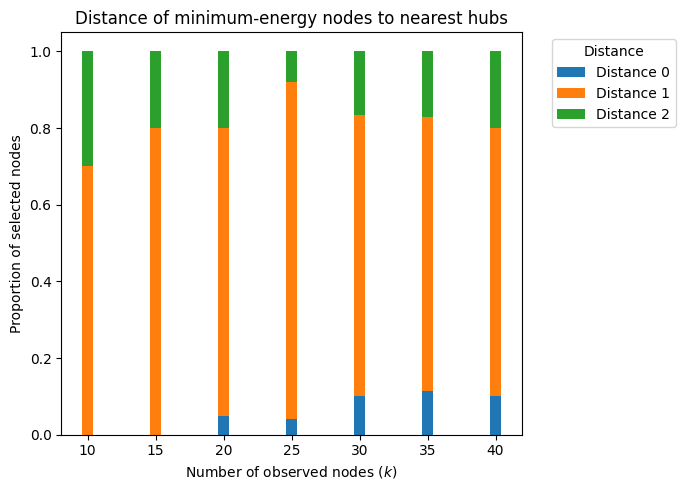

In [ ]:
from collections import Counter
dist_dict = {
    10: dist_10,
    15: dist_15,
    20: dist_20,
    25: dist_25,
    30: dist_30,
    35: dist_35,
    40: dist_40,
}

# --------------------------------------------------
# FIND ALL POSSIBLE DISTANCES
# --------------------------------------------------
all_distances = sorted(
    set(d for vals in dist_dict.values() for d in vals)
)

# --------------------------------------------------
# BUILD NORMALIZED COUNTS
# --------------------------------------------------
data = {}

for k, vals in dist_dict.items():

    counts = Counter(vals)

    total = len(vals)

    data[k] = [
        counts.get(d, 0) / total
        for d in all_distances
    ]

# --------------------------------------------------
# STACKED BARPLOT
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

bottom = np.zeros(len(dist_dict))

ks = list(dist_dict.keys())

for i, d in enumerate(all_distances):

    values = [data[k][i] for k in ks]

    ax.bar(
        ks,
        values,
        bottom=bottom,
        label=f"Distance {d}"
    )

    bottom += values

# --------------------------------------------------
# LABELS
# --------------------------------------------------
ax.set_xlabel(r"Number of observed nodes ($k$)")
ax.set_ylabel("Proportion of selected nodes")
ax.set_title("Distance of minimum-energy nodes to nearest hubs")

ax.legend(title="Distance", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(figures_dir / "distance_to_hubs_stacked_bar.png", dpi=300)
plt.show()